In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
train_dir = "/content/drive/My Drive/AI/Traffic_Sign_-2/Train/"
test_dir = "/content/drive/My Drive/AI/Traffic_Sign_-2/Test/"

In [ ]:
!pip install numpy matplotlib seaborn scikit-learn pillow tensorflow

In [4]:
import os
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import load_model

import time

In [ ]:
def total_images_through_classes(directory):
    class_totals = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            class_totals[class_name] = len(image_files)
    return class_totals

In [ ]:
train_totals = total_images_through_classes(train_dir)

In [ ]:
total_train_count = 0
total_valid_count = 0
print("Training Images:")
print("Classes:")
for classs, count in train_totals.items():
    total_train_count += count
    print(f"'{classs}': {count} images")
print()
print(f"Total Training Images Count: {total_train_count}")
print(f"Total Images Count: {total_train_count}")

Training Images:
Classes:
'SpeedLimit': 5344 images
'No Entry': 2346 images
'Cautions': 1338 images
'Crossings': 1458 images
'DIrection': 2368 images

Total Training Images Count: 12854
Total Images Count: 12854


In [ ]:
import os
import shutil
import random

# Set paths
original_dataset_dir = '/content/drive/My Drive/AI/Traffic_Sign_-2/Train/'  # Original train folder
train_dir = original_dataset_dir  # You keep the training images here
test_dir = '/content/drive/My Drive/AI/Traffic_Sign_-2/Test/'  # Target test folder

# Create test directories if they don't exist
os.makedirs(test_dir, exist_ok=True)

# Set split ratio
test_ratio = 0.2
random.seed(42)

# Split images per class
for class_name in os.listdir(original_dataset_dir):
    class_path = os.path.join(original_dataset_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)
    split_idx = int(len(images) * (1 - test_ratio))

    train_images = images[:split_idx]
    test_images = images[split_idx:]

    # Ensure test class folder exists
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

    # Move test images
    for img in test_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(test_dir, class_name, img)
        shutil.move(src, dst)

    print(f"{class_name}: {len(train_images)} train / {len(test_images)} test")


SpeedLimit: 4275 train / 1069 test
No Entry: 1876 train / 470 test
Cautions: 1070 train / 268 test
Crossings: 1166 train / 292 test
DIrection: 1894 train / 474 test


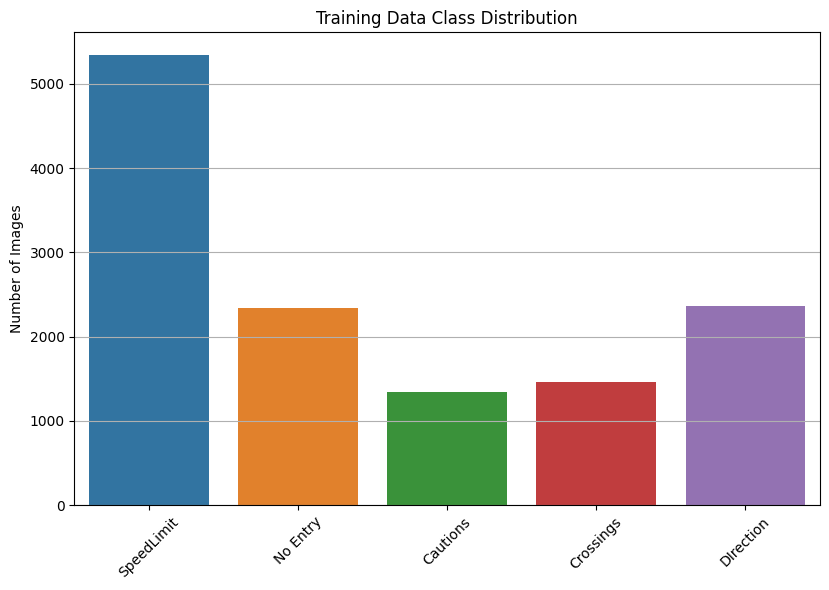

In [ ]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=list(train_totals.keys()), y=list(train_totals.values()), hue=list(train_totals.keys()), legend=False)
plt.title('Training Data Class Distribution')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

In [ ]:
import os

test_path = "/content/drive/My Drive/AI/Traffic_Sign_-2/Test/"
total_test = sum(
    len(files)
    for cls in os.listdir(test_path)
    if os.path.isdir(os.path.join(test_path, cls))
    for files in [os.listdir(os.path.join(test_path, cls))]
)
print(f"Images in test/: {total_test}")

Images in test/: 5784


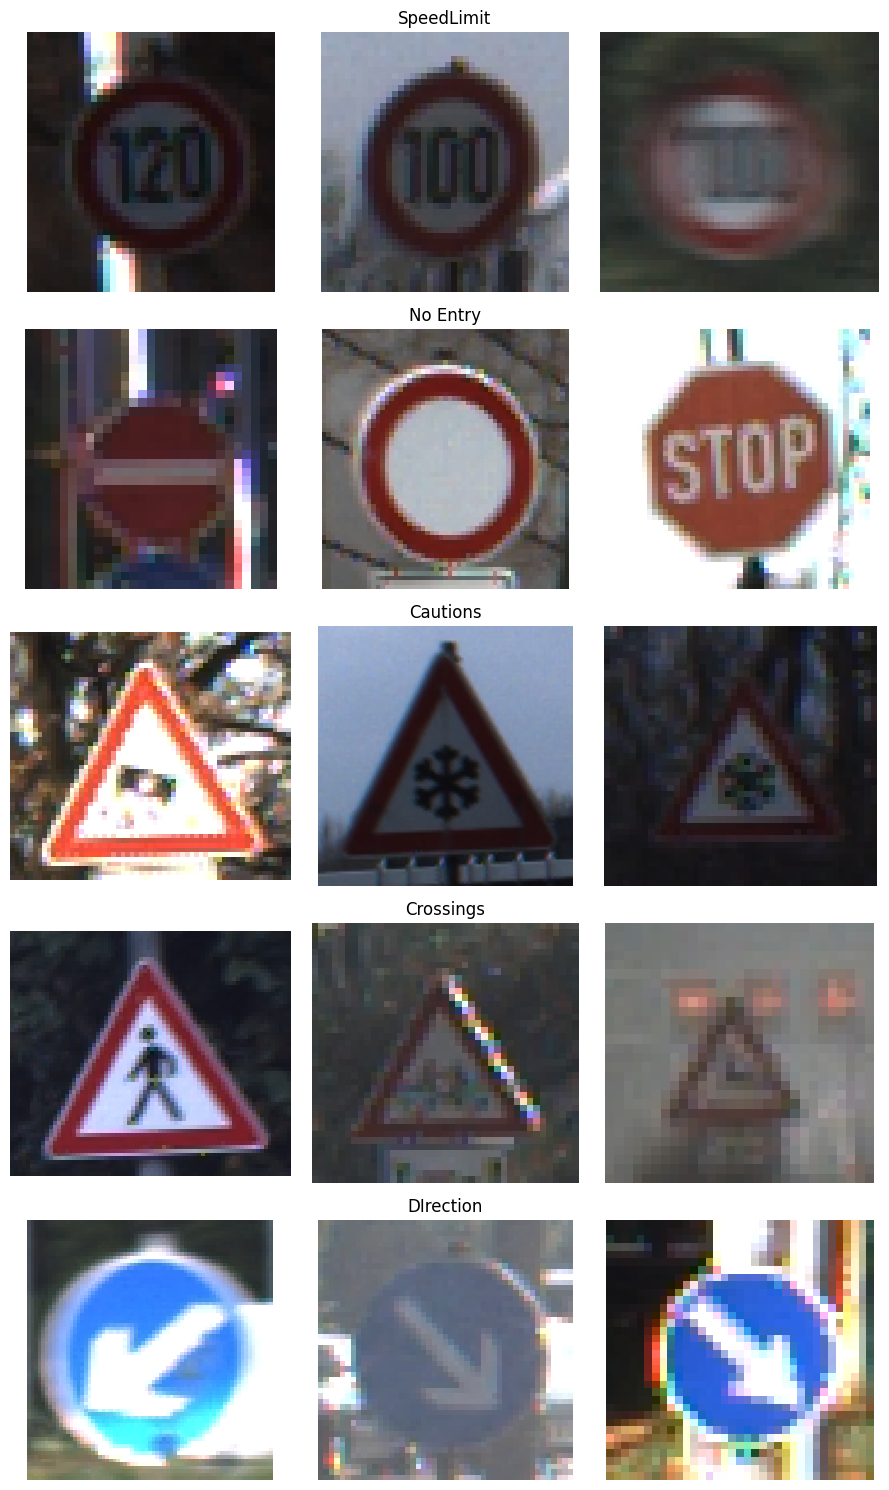

In [ ]:
from PIL import Image, UnidentifiedImageError
import os
import random
import matplotlib.pyplot as plt

train_dir = "/content/drive/My Drive/AI/Traffic_Sign_-2/Train/"
class_names = os.listdir(train_dir)

plt.figure(figsize=(3 * 3, len(class_names) * 3))

for i, cls in enumerate(class_names):
    cls_path = os.path.join(train_dir, cls)
    images = [img for img in os.listdir(cls_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    selected_images = random.sample(images, min(3, len(images)))

    for j, img_name in enumerate(selected_images):
        img_path = os.path.join(cls_path, img_name)
        try:
            image = Image.open(img_path).convert('RGB')
            plt.subplot(len(class_names), 3, i * 3 + j + 1)
            plt.imshow(image)
            plt.axis('off')
            if j == 1:
                plt.title(cls)
        except UnidentifiedImageError:
            print(f" Skipping unreadable image: {img_path}")

plt.tight_layout()
plt.show()


In [ ]:
def remove_corrupted_images(directory):
    removed = 0
    for subdir, _, files in os.walk(directory):
        for file in files:
            filepath = os.path.join(subdir, file)
            try:
                img = Image.open(filepath)
                img.verify()
            except (IOError, SyntaxError):
                print(f"Removing corrupt image: {filepath}")
                os.remove(filepath)
                removed += 1
    print(f"Total corrupt images removed: {removed}")

In [ ]:
remove_corrupted_images(train_dir)
remove_corrupted_images(test_dir)

Total corrupt images removed: 0
Total corrupt images removed: 0


In [ ]:
import os
from PIL import Image

def image_formats(folder_path):
    format_count = {}

    for subdir, _, files in os.walk(folder_path):
        for file in files:
            filepath = os.path.join(subdir, file)
            try:
                img = Image.open(filepath)
                img_format = img.format

                if img_format in format_count:
                    format_count[img_format] += 1
                else:
                    format_count[img_format] = 1
            except Exception as e:
                print(f"Error with image {filepath}: {e}")

    return format_count

formats_train = image_formats(train_dir)
formats_test = image_formats(test_dir)
print(formats_train)
print(formats_test)

{'PNG': 10281}
{'PNG': 5794}


In [ ]:
def collect_image_sizes(root_dir):
    widths, heights = [], []
    image_count = 0
    for folder, _, files in os.walk(root_dir):
        for fname in files:
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                path = os.path.join(folder, fname)
                try:
                    with Image.open(path) as img:
                        w, h = img.size
                        widths.append(w)
                        heights.append(h)
                    image_count += 1
                except Exception as e:
                    print(f"Error processing file {fname}: {e}")

    if image_count == 0:
        print("No images were processed.")
        return np.array([]), np.array([])

    return np.array(widths), np.array(heights)

w, h = collect_image_sizes(train_dir)

if w.size > 0 and h.size > 0:
    print(f"Widths:  min={w.min()}, max={w.max()}, mean={w.mean():.1f}")
    print(f"Heights: min={h.min()}, max={h.max()}, mean={h.mean():.1f}")
else:
    print("No valid image sizes were found.")


Widths:  min=25, max=221, mean=48.7
Heights: min=25, max=211, mean=48.7


In [ ]:
targetSize = (224, 224) #Target Size for resizing
batch_size = 64
num_classes = 5
validation_split = 0.2 #20% for validation

In [ ]:
train_datagen = ImageDataGenerator(
    rescale = 1./255, # we're normalizing here from 0 to 1 (range of rgb values 1 to 255)
    rotation_range = 10,
    width_shift_range = 0.05,
    height_shift_range = 0.05,
    zoom_range = 0.05,
    horizontal_flip = True,
    validation_split = 0.2 ##20% of the data will be used for validation
)

#data augmentation is performed only for the training dataset


In [ ]:
training_dataset = train_datagen.flow_from_directory(
    train_dir,
    target_size = targetSize,
    batch_size = batch_size,
    class_mode = 'sparse',
    shuffle = True,
    seed = 123,
    subset = "training"
)

Found 8226 images belonging to 5 classes.


In [ ]:
validation_dataset = train_datagen.flow_from_directory(
    train_dir,
    target_size = targetSize,
    batch_size = batch_size,
    class_mode = 'sparse',
    shuffle = False,
    seed = 123,
    subset = "validation"
)

Found 2055 images belonging to 5 classes.


In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_dataset = test_datagen.flow_from_directory(
    test_dir,
    target_size=targetSize,
    batch_size=64,
    class_mode='sparse',
    shuffle=False,
    seed=123
)

Found 5784 images belonging to 5 classes.


In [ ]:
training_dataset.class_indices.items()

dict_items([('Cautions', 0), ('Crossings', 1), ('DIrection', 2), ('No Entry', 3), ('SpeedLimit', 4)])

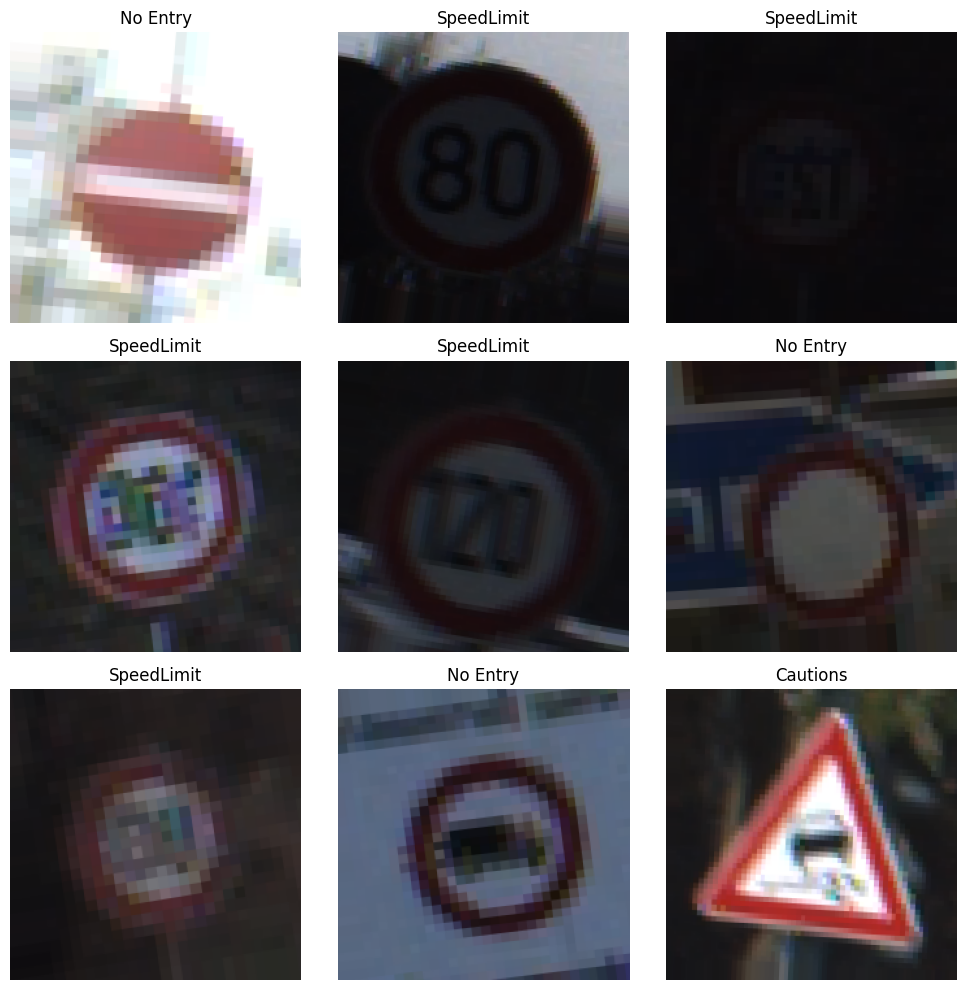

In [ ]:
class_names = {}
for class_name, class_index in training_dataset.class_indices.items():
    class_names[class_index] = class_name
images, labels = next(training_dataset)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.title(f"{class_names[int(labels[i])]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
input_shape = (224, 224, 3)
num_classes = 5
batch_size = 64

baseline_adam_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

baseline_adam_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,179,461 (42.65 MB)

 Trainable params: 11,179,461 (42.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

def build_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(2, 2),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        Flatten(),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    return model


In [ ]:
callbacks = [
    ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
]


In [ ]:
baseline_sgd_model = build_model()
baseline_sgd_model.compile(
    optimizer=SGD(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = baseline_sgd_model.fit(
    training_dataset,
    validation_data=validation_dataset,
    epochs=15,
    batch_size=batch_size,
    callbacks=callbacks
)

Epoch 1/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.4736 - loss: 1.3975 - val_accuracy: 0.5835 - val_loss: 1.2364
Epoch 2/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.6742 - loss: 0.8917 - val_accuracy: 0.8010 - val_loss: 0.5180
Epoch 3/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.7743 - loss: 0.5752 - val_accuracy: 0.7854 - val_loss: 0.5293
Epoch 4/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.8107 - loss: 0.4788 - val_accuracy: 0.8029 - val_loss: 0.4237
Epoch 5/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.8310 - loss: 0.4117 - val_accuracy: 0.8477 - val_loss: 0.3496
Epoch 6/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.8442 - loss: 0.3710 - val_accuracy: 0.8034 - val_loss: 0.4063
Epoch 7/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.8694 - loss: 0.3196 - val_accuracy: 0.8375 - val_loss: 0.3417
Epoch 8/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.8769 - loss: 0.3044 - val_accu

In [ ]:
baseline_adam_model = build_model()
baseline_adam_model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_adam = baseline_adam_model.fit(
    training_dataset,
    validation_data=validation_dataset,
    epochs=15,
    batch_size=batch_size,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.5961 - loss: 1.1431 - val_accuracy: 0.8271 - val_loss: 0.3922
Epoch 2/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.8122 - loss: 0.4378 - val_accuracy: 0.7690 - val_loss: 0.4489
Epoch 3/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.8411 - loss: 0.3506 - val_accuracy: 0.8584 - val_loss: 0.2670
Epoch 4/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8571 - loss: 0.3321 - val_accuracy: 0.8212 - val_loss: 0.3967
Epoch 5/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.8931 - loss: 0.2717 - val_accuracy: 0.8346 - val_loss: 0.3813
Epoch 6/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8849 - loss: 0.2893 - val_accuracy: 0.7854 - val_loss: 0.5643
Epoch 7/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.9165 - loss: 0.2016 - val_accuracy: 0.8405 - val_loss: 0.3321
Epoch 8/15
43/43 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.9235 - loss: 0.1924 - val_accuracy: 0.8689 - val_loss:

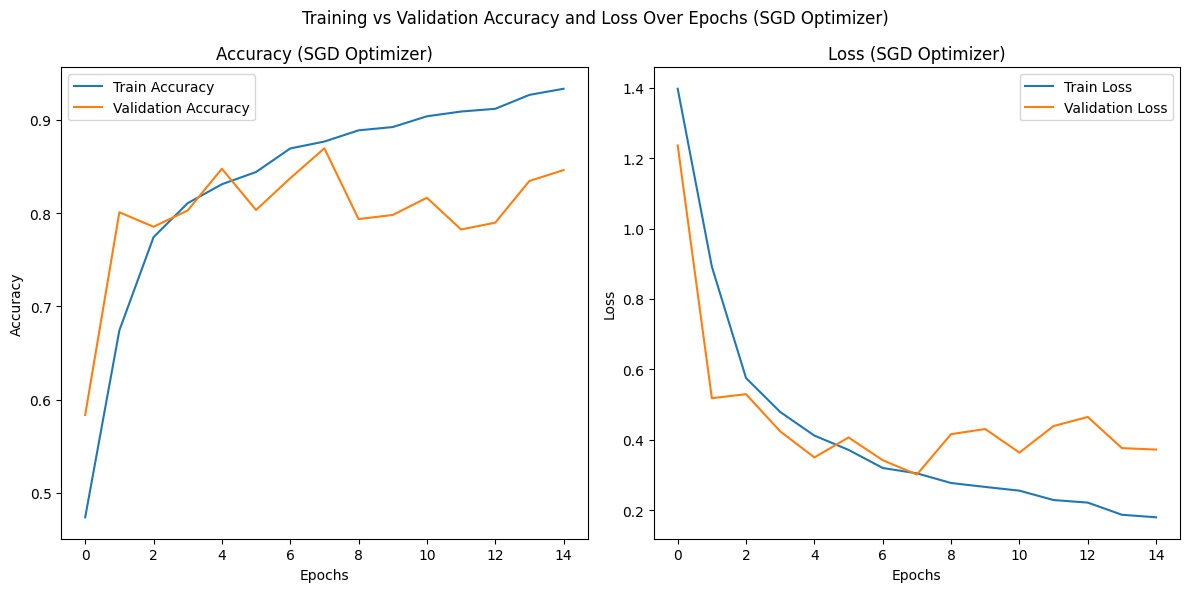

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_sgd.history['accuracy'], label='Train Accuracy')
plt.plot(history_sgd.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy (SGD Optimizer)')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_sgd.history['loss'], label='Train Loss')
plt.plot(history_sgd.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss (SGD Optimizer)')

plt.suptitle('Training vs Validation Accuracy and Loss Over Epochs (SGD Optimizer)')
plt.tight_layout()
plt.show()


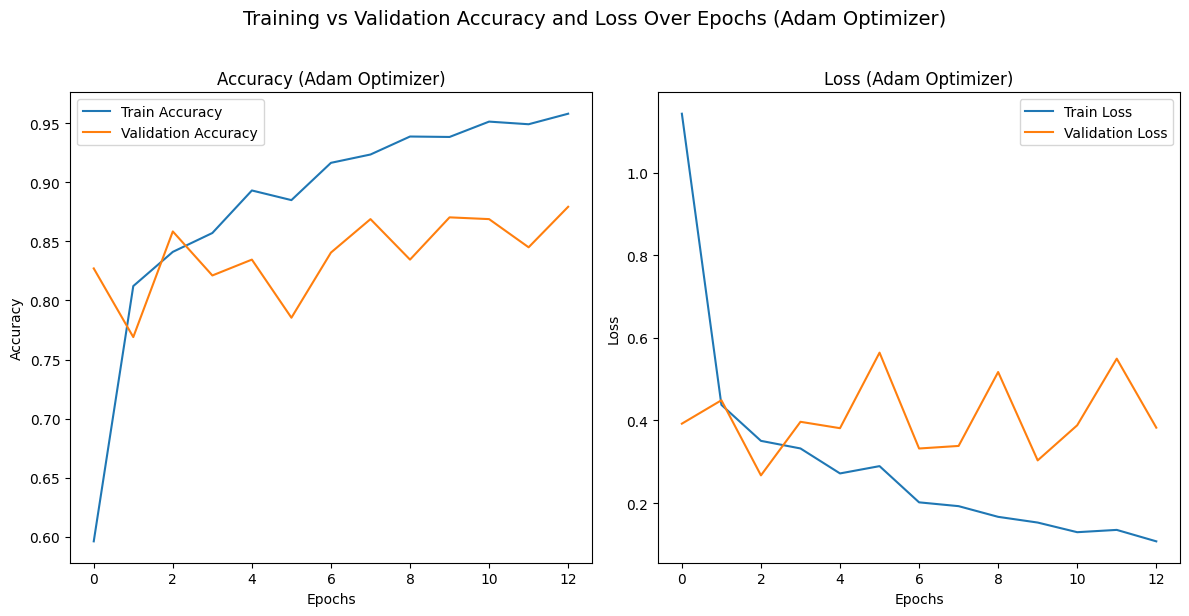

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Accuracy subplot
plt.subplot(1, 2, 1)
plt.plot(history_adam.history['accuracy'], label='Train Accuracy')
plt.plot(history_adam.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy (Adam Optimizer)')
plt.legend()

# Loss subplot
plt.subplot(1, 2, 2)
plt.plot(history_adam.history['loss'], label='Train Loss')
plt.plot(history_adam.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss (Adam Optimizer)')
plt.legend()

plt.suptitle("Training vs Validation Accuracy and Loss Over Epochs (Adam Optimizer)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = baseline_sgd_model.evaluate(test_dataset)

# Print test results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


91/91 ━━━━━━━━━━━━━━━━━━━━ 25s 278ms/step - accuracy: 0.8904 - loss: 0.2466
Test Loss: 0.2466
Test Accuracy: 0.8904


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Get true labels (only works if test_dataset is a DirectoryIterator or similar)
y_true = test_dataset.classes

# Predict labels
y_pred_probs = baseline_sgd_model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

# Fix class names to only include those that are in y_true
all_class_names = list(test_dataset.class_indices.keys())
present_labels = np.unique(y_true)
present_class_names = [all_class_names[i] for i in present_labels]

# Print classification report
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, labels=present_labels, target_names=present_class_names))


91/91 ━━━━━━━━━━━━━━━━━━━━ 25s 268ms/step
              precision    recall  f1-score   support

    Cautions       0.75      0.52      0.62       601
   Crossings       0.67      0.84      0.74       655
   DIrection       0.99      0.99      0.99      1067
    No Entry       0.97      0.81      0.88      1055
  SpeedLimit       0.92      0.99      0.95      2406

    accuracy                           0.89      5784
   macro avg       0.86      0.83      0.84      5784
weighted avg       0.89      0.89      0.89      5784



In [ ]:
test_loss_adam, test_accuracy_adam = baseline_adam_model.evaluate(test_dataset)

print(f"Test Loss: {test_loss_adam:.4f}")
print(f"Test Accuracy: {test_accuracy_adam:.4f}")

199/199 ━━━━━━━━━━━━━━━━━━━━ 53s 265ms/step - accuracy: 0.8586 - loss: 0.3046
Test Loss: 0.3046
Test Accuracy: 0.8586


In [ ]:
# Get true and predicted labels
y_true = test_dataset.classes
y_pred_probs = baseline_adam_model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get all class names from the test dataset
all_class_names = list(test_dataset.class_indices.keys())

# Get only the class indices present in y_true
present_labels = sorted(np.unique(y_true))
present_class_names = [all_class_names[i] for i in present_labels]

# Print classification report for only present classes
print(classification_report(y_true, y_pred, labels=present_labels, target_names=present_class_names))


199/199 ━━━━━━━━━━━━━━━━━━━━ 56s 276ms/step
              precision    recall  f1-score   support

    Cautions       0.70      0.30      0.42      1323
   Crossings       0.57      0.87      0.69      1443
   DIrection       0.98      1.00      0.99      2341
    No Entry       0.96      0.75      0.85      2317
  SpeedLimit       0.90      0.98      0.94      5285

    accuracy                           0.86     12709
   macro avg       0.82      0.78      0.78     12709
weighted avg       0.87      0.86      0.85     12709



199/199 ━━━━━━━━━━━━━━━━━━━━ 50s 252ms/step


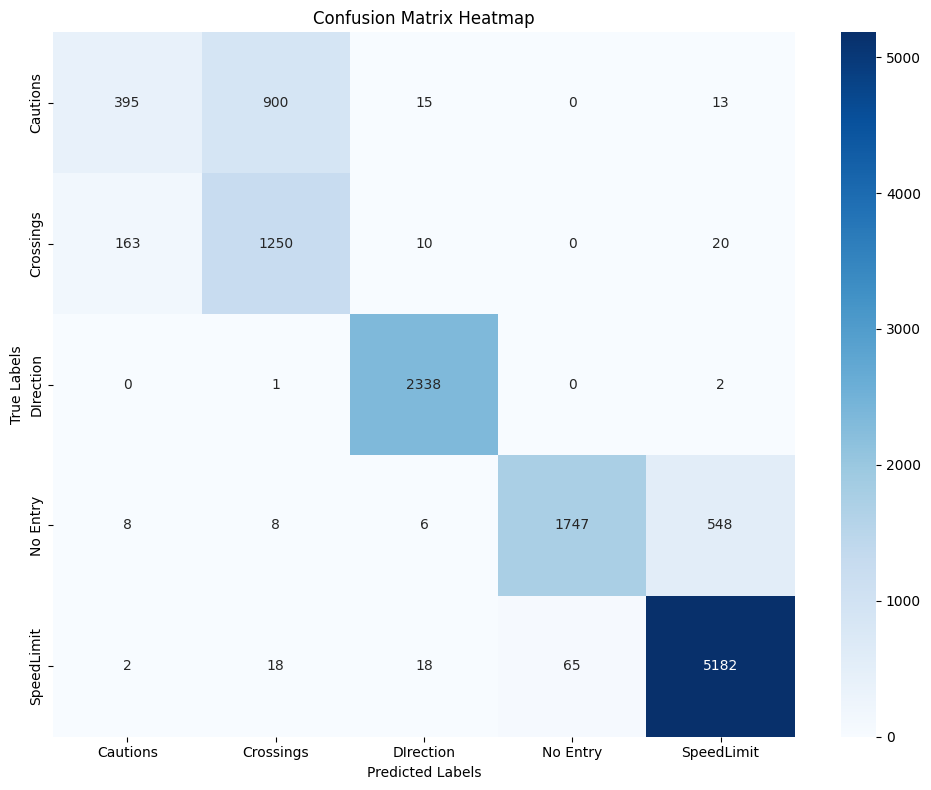

In [ ]:
y_true = test_dataset.classes
y_pred_probs = baseline_adam_model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=test_dataset.class_indices.keys(),
            yticklabels=test_dataset.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
input_shape = (224, 224, 3)
num_classes = 5

deeper_sgd_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001), input_shape=input_shape),
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(num_classes, activation='softmax')
])

deeper_sgd_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 20, 20, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     6,553,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,767,589 (29.63 MB)

 Trainable params: 7,767,589 (29.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
input_shape = (224, 224, 3)
num_classes = 5

deeper_sgd_model_2 = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005), input_shape=input_shape),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(256, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),

    Dense(num_classes, activation='softmax')
])

deeper_sgd_model_2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 220, 220, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 106, 106, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 51, 51, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 49, 49, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 20, 20, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25600)          │             

 Total params: 7,773,221 (29.65 MB)

 Trainable params: 7,770,405 (29.64 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [ ]:
input_shape = (224, 224, 3)
num_classes = 5

deeper_adam_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005), input_shape=input_shape),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(256, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=l2(0.0005)),
    BatchNormalization(),

    Dense(num_classes, activation='softmax')
])

deeper_adam_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 220, 220, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 106, 106, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 51, 51, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 49, 49, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 20, 20, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25600)          │             

 Total params: 7,773,221 (29.65 MB)

 Trainable params: 7,770,405 (29.64 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [ ]:
deeper_sgd_model.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9), #setting the learning rate and the momentum (it helps in faster convergence and controls extreme oscillations)
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
deeper_sgd_model_2.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
callbacks_sgd = [
    ModelCheckpoint("deeper_sgd_model.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)
]

history_deeper_sgd = deeper_sgd_model.fit(
    training_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=callbacks_sgd
)


Epoch 1/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - accuracy: 0.4145 - loss: 3.0718 - val_accuracy: 0.4161 - val_loss: 3.0119 - learning_rate: 0.0010
Epoch 2/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.4158 - loss: 3.0035 - val_accuracy: 0.4161 - val_loss: 2.9815 - learning_rate: 0.0010
Epoch 3/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.4160 - loss: 2.9522 - val_accuracy: 0.4127 - val_loss: 2.8798 - learning_rate: 0.0010
Epoch 4/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.4643 - loss: 2.8225 - val_accuracy: 0.5105 - val_loss: 2.6242 - learning_rate: 0.0010
Epoch 5/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.6048 - loss: 2.5278 - val_accuracy: 0.5582 - val_loss: 2.5430 - learning_rate: 0.0010
Epoch 6/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.7471 - loss: 2.1809 - val_accuracy: 0.7324 - val_loss: 2.1436 - learning_rate: 0.0010
Epoch 7/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.8209 - loss: 1.

In [ ]:
callbacks_deeper_sgd_2 = [
    ModelCheckpoint("deeper_sgd_model_2.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)
]

history_deeper_sgd_2 = deeper_sgd_model_2.fit(
    training_dataset,
    validation_data=validation_dataset,
    epochs=30, # Increased epochs for deeper model training
    callbacks=callbacks_deeper_sgd_2
)


Epoch 1/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.7405 - loss: 1.4966 - val_accuracy: 0.1839 - val_loss: 2.5710 - learning_rate: 0.0010
Epoch 2/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.9161 - loss: 1.0278 - val_accuracy: 0.2530 - val_loss: 2.6853 - learning_rate: 0.0010
Epoch 3/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.9468 - loss: 0.9473 - val_accuracy: 0.6895 - val_loss: 1.5937 - learning_rate: 0.0010
Epoch 4/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.9619 - loss: 0.8975 - val_accuracy: 0.8856 - val_loss: 1.0667 - learning_rate: 0.0010
Epoch 5/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.9733 - loss: 0.8647 - val_accuracy: 0.8774 - val_loss: 1.1119 - learning_rate: 0.0010
Epoch 6/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.9841 - loss: 0.8345 - val_accuracy: 0.8866 - val_loss: 1.0963 - learning_rate: 0.0010
Epoch 7/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.9865 - loss: 0.

In [ ]:
deeper_adam_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
callbacks_deeper_adam = [
    ModelCheckpoint("deeper_adam_model.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)
]

history_deeper_adam = deeper_adam_model.fit(
    training_dataset,
    validation_data=validation_dataset,
    epochs=30, # Increased epochs for deeper model training
    callbacks=callbacks_deeper_adam
)


Epoch 1/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.8262 - loss: 1.3381 - val_accuracy: 0.2745 - val_loss: 5.4639 - learning_rate: 0.0010
Epoch 2/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.9468 - loss: 0.9857 - val_accuracy: 0.3547 - val_loss: 3.9640 - learning_rate: 0.0010
Epoch 3/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.9709 - loss: 0.8372 - val_accuracy: 0.4749 - val_loss: 3.6414 - learning_rate: 0.0010
Epoch 4/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.9847 - loss: 0.7087 - val_accuracy: 0.8049 - val_loss: 1.2810 - learning_rate: 0.0010
Epoch 5/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.9786 - loss: 0.6540 - val_accuracy: 0.8710 - val_loss: 1.2175 - learning_rate: 0.0010
Epoch 6/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.9866 - loss: 0.5723 - val_accuracy: 0.7523 - val_loss: 1.4799 - learning_rate: 0.0010
Epoch 7/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.9835 - loss: 0.

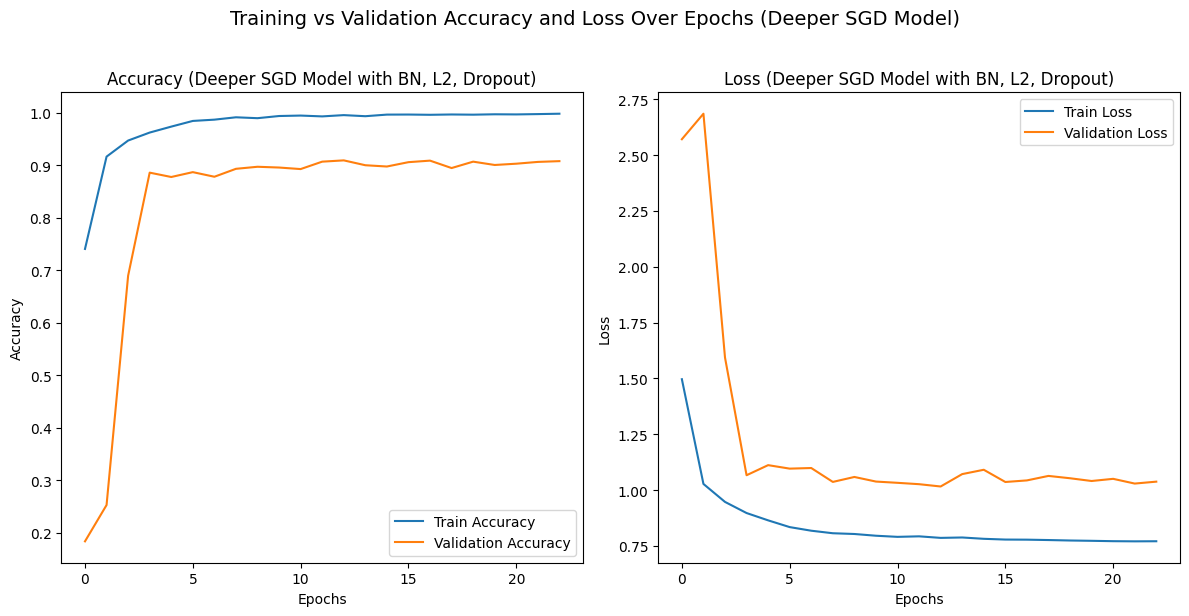

In [ ]:
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_deeper_sgd_2.history['accuracy'], label='Train Accuracy')
plt.plot(history_deeper_sgd_2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy (Deeper SGD Model with BN, L2, Dropout)')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_deeper_sgd_2.history['loss'], label='Train Loss')
plt.plot(history_deeper_sgd_2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss (Deeper SGD Model with BN, L2, Dropout)')

plt.suptitle('Training vs Validation Accuracy and Loss Over Epochs (Deeper SGD Model)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
test_loss_deeper_sgd_2, test_accuracy_deeper_sgd_2 = deeper_sgd_model_2.evaluate(test_dataset)

print(f"Deeper SGD Model (with BN, L2, Dropout) Test Loss: {test_loss_deeper_sgd_2:.4f}")
print(f"Deeper SGD Model (with BN, L2, Dropout) Test Accuracy: {test_accuracy_deeper_sgd_2:.4f}")


91/91 ━━━━━━━━━━━━━━━━━━━━ 29s 314ms/step - accuracy: 0.9799 - loss: 0.8237
Deeper SGD Model (with BN, L2, Dropout) Test Loss: 0.8237
Deeper SGD Model (with BN, L2, Dropout) Test Accuracy: 0.9799


In [ ]:
y_true = test_dataset.classes
y_pred_probs_deeper_sgd_2 = deeper_sgd_model_2.predict(test_dataset)
y_pred_deeper_sgd_2 = np.argmax(y_pred_probs_deeper_sgd_2, axis=1)

all_class_names = list(test_dataset.class_indices.keys())
present_labels = sorted(np.unique(y_true))
present_class_names = [all_class_names[i] for i in present_labels]

print("Classification Report for Deeper SGD Model (with BN, L2, Dropout):")
print(classification_report(y_true, y_pred_deeper_sgd_2, labels=present_labels, target_names=present_class_names))


91/91 ━━━━━━━━━━━━━━━━━━━━ 27s 282ms/step
Classification Report for Deeper SGD Model (with BN, L2, Dropout):
              precision    recall  f1-score   support

    Cautions       0.91      0.91      0.91       601
   Crossings       0.92      0.92      0.92       655
   DIrection       0.99      1.00      0.99      1067
    No Entry       1.00      1.00      1.00      1055
  SpeedLimit       1.00      1.00      1.00      2406

    accuracy                           0.98      5784
   macro avg       0.96      0.96      0.96      5784
weighted avg       0.98      0.98      0.98      5784



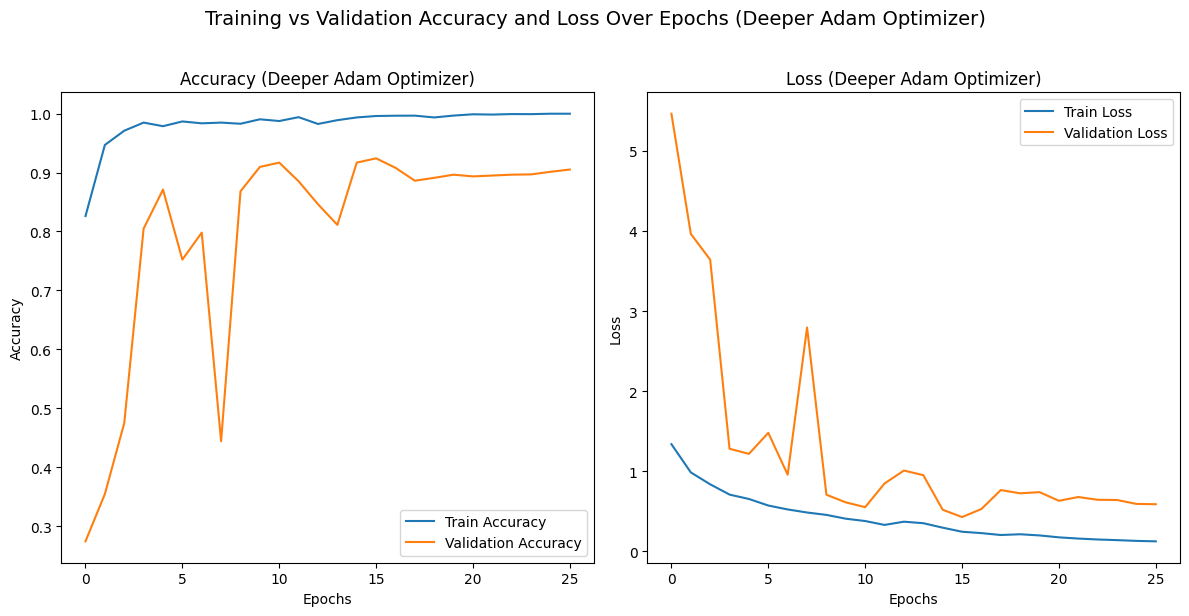

In [ ]:
plt.figure(figsize=(12, 6))

# Accuracy subplot
plt.subplot(1, 2, 1)
plt.plot(history_deeper_adam.history['accuracy'], label='Train Accuracy')
plt.plot(history_deeper_adam.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy (Deeper Adam Optimizer)')
plt.legend()

# Loss subplot
plt.subplot(1, 2, 2)
plt.plot(history_deeper_adam.history['loss'], label='Train Loss')
plt.plot(history_deeper_adam.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss (Deeper Adam Optimizer)')
plt.legend()

plt.suptitle("Training vs Validation Accuracy and Loss Over Epochs (Deeper Adam Optimizer)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
test_loss_deeper_adam, test_accuracy_deeper_adam = deeper_adam_model.evaluate(test_dataset)

print(f"Deeper Adam Model (with BN, L2, Dropout) Test Loss: {test_loss_deeper_adam:.4f}")
print(f"Deeper Adam Model (with BN, L2, Dropout) Test Accuracy: {test_accuracy_deeper_adam:.4f}")


91/91 ━━━━━━━━━━━━━━━━━━━━ 27s 293ms/step - accuracy: 0.9846 - loss: 0.2644
Deeper Adam Model (with BN, L2, Dropout) Test Loss: 0.2644
Deeper Adam Model (with BN, L2, Dropout) Test Accuracy: 0.9846


In [ ]:
y_true = test_dataset.classes
y_pred_probs_deeper_adam = deeper_adam_model.predict(test_dataset)
y_pred_deeper_adam = np.argmax(y_pred_probs_deeper_adam, axis=1)

all_class_names = list(test_dataset.class_indices.keys())
present_labels = sorted(np.unique(y_true))
present_class_names = [all_class_names[i] for i in present_labels]

print("Classification Report for Deeper Adam Model (with BN, L2, Dropout):")
print(classification_report(y_true, y_pred_deeper_adam, labels=present_labels, target_names=present_class_names))


91/91 ━━━━━━━━━━━━━━━━━━━━ 27s 275ms/step
Classification Report for Deeper Adam Model (with BN, L2, Dropout):
              precision    recall  f1-score   support

    Cautions       0.98      0.88      0.93       601
   Crossings       0.90      0.98      0.94       655
   DIrection       1.00      1.00      1.00      1067
    No Entry       1.00      1.00      1.00      1055
  SpeedLimit       1.00      1.00      1.00      2406

    accuracy                           0.98      5784
   macro avg       0.97      0.97      0.97      5784
weighted avg       0.99      0.98      0.98      5784



In [ ]:
input_shape = (224, 224, 3)
num_classes = 5

deep_adam_no_bn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005), input_shape=input_shape),
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.0005)),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(256, activation='relu', kernel_regularizer=l2(0.0005)),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=l2(0.0005)),
    Dropout(0.2),

    Dense(64, activation='relu', kernel_regularizer=l2(0.0005)),

    Dense(num_classes, activation='softmax')
])

deep_adam_no_bn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 20, 20, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │     6,553,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,767,589 (29.63 MB)

 Trainable params: 7,767,589 (29.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
deep_adam_no_bn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_deep_adam_no_bn = [
    ModelCheckpoint("deep_adam_no_bn_model.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)
]

history_deep_adam_no_bn = deep_adam_no_bn_model.fit(
    training_dataset,
    validation_data=validation_dataset,
    epochs=30,
    callbacks=callbacks_deep_adam_no_bn
)


Epoch 1/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.4644 - loss: 1.6313 - val_accuracy: 0.8005 - val_loss: 0.8332 - learning_rate: 0.0010
Epoch 2/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.7595 - loss: 0.7408 - val_accuracy: 0.8365 - val_loss: 0.5512 - learning_rate: 0.0010
Epoch 3/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.8197 - loss: 0.5546 - val_accuracy: 0.8443 - val_loss: 0.4795 - learning_rate: 0.0010
Epoch 4/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.8670 - loss: 0.4370 - val_accuracy: 0.8005 - val_loss: 0.8058 - learning_rate: 0.0010
Epoch 5/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.8995 - loss: 0.3610 - val_accuracy: 0.8730 - val_loss: 0.4365 - learning_rate: 0.0010
Epoch 6/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.9382 - loss: 0.2885 - val_accuracy: 0.8720 - val_loss: 0.4423 - learning_rate: 0.0010
Epoch 7/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.9610 - loss: 0.

In [ ]:
test_loss_deep_adam_no_bn, test_accuracy_deep_adam_no_bn = deep_adam_no_bn_model.evaluate(test_dataset)

print(f"Deeper Adam Model (without BN) Test Loss: {test_loss_deep_adam_no_bn:.4f}")
print(f"Deeper Adam Model (without BN) Test Accuracy: {test_accuracy_deep_adam_no_bn:.4f}")


91/91 ━━━━━━━━━━━━━━━━━━━━ 23s 255ms/step - accuracy: 0.9279 - loss: 0.3093
Deeper Adam Model (without BN) Test Loss: 0.3093
Deeper Adam Model (without BN) Test Accuracy: 0.9279


In [7]:
input_shape = (224, 224, 3) # Define input_shape as it's used here
num_classes = 5 # Define num_classes as it's used here

# Load the pre-trained MobileNetV2 model
base_model = MobileNetV2(input_shape=input_shape,
                         include_top=False, # Do not include the ImageNet classifier at the top
                         weights='imagenet') # Load weights pre-trained on ImageNet

# Freeze the convolutional base to prevent its weights from being updated during training
base_model.trainable = False

# Create a new model on top
inputs = Input(shape=input_shape)
x = base_model(inputs, training=False) # Ensure base_model runs in inference mode
x = GlobalAveragePooling2D()(x) # Convert features to a single 1280-element vector per image
x = Dropout(0.2)(x) # Add a dropout layer for regularization
outputs = Dense(num_classes, activation='softmax')(x) # Add a new classifier layer for our classes

transfer_model = Model(inputs, outputs)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
train_dir = "/content/drive/My Drive/AI/Traffic_Sign_-2/Train/"
targetSize = (224, 224)
batch_size = 64
num_classes = 5
validation_split = 0.2

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 10,
    width_shift_range = 0.05,
    height_shift_range = 0.05,
    zoom_range = 0.05,
    horizontal_flip = True,
    validation_split = 0.2
)

training_dataset = train_datagen.flow_from_directory(
    train_dir,
    target_size = targetSize,
    batch_size = batch_size,
    class_mode = 'sparse',
    shuffle = True,
    seed = 123,
    subset = "training"
)

validation_dataset = train_datagen.flow_from_directory(
    train_dir,
    target_size = targetSize,
    batch_size = batch_size,
    class_mode = 'sparse',
    shuffle = False,
    seed = 123,
    subset = "validation"
)

Found 2154 images belonging to 5 classes.
Found 536 images belonging to 5 classes.


In [10]:
transfer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_transfer_ft = [
    ModelCheckpoint("transfer_model_feature_extraction.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)
]

history_transfer_ft = transfer_model.fit(
    training_dataset,
    validation_data=validation_dataset,
    epochs=10, # Train for fewer epochs during feature extraction
    callbacks=callbacks_transfer_ft
)


Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 920s 27s/step - accuracy: 0.5859 - loss: 1.0915 - val_accuracy: 0.6996 - val_loss: 0.6770 - learning_rate: 0.0010
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8245 - loss: 0.4733 - val_accuracy: 0.7966 - val_loss: 0.4892 - learning_rate: 0.0010
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.8756 - loss: 0.3407 - val_accuracy: 0.8004 - val_loss: 0.4481 - learning_rate: 0.0010
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9020 - loss: 0.2928 - val_accuracy: 0.8209 - val_loss: 0.4041 - learning_rate: 0.0010
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9183 - loss: 0.2512 - val_accuracy: 0.8377 - val_loss: 0.3591 - learning_rate: 0.0010
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9304 - loss: 0.2158 - val_accuracy: 0.8507 - val_loss: 0.3624 - learning_rate: 0.0010
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9318 - loss: 0.2038 - val_accuracy

In [14]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_dataset = test_datagen.flow_from_directory(
    test_dir,
    target_size=targetSize,
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False,
    seed=123
)

test_loss_transfer_ft, test_accuracy_transfer_ft = transfer_model.evaluate(test_dataset)

print(f"Transfer Learning Model (Feature Extraction) Test Loss: {test_loss_transfer_ft:.4f}")
print(f"Transfer Learning Model (Feature Extraction) Test Accuracy: {test_accuracy_transfer_ft:.4f}")

Found 13383 images belonging to 5 classes.
210/210 ━━━━━━━━━━━━━━━━━━━━ 4058s 19s/step - accuracy: 0.9088 - loss: 0.2373
Transfer Learning Model (Feature Extraction) Test Loss: 0.2373
Transfer Learning Model (Feature Extraction) Test Accuracy: 0.9088


In [15]:
# Unfreeze the base model
base_model.trainable = True

# Fine-tune from this layer onwards
fine_tune_at = 100 # Unfreeze all layers after a certain point (e.g., after 100 layers)

# Freeze all layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Compile the model with a very low learning rate
transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001), # Use a lower learning rate for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 1,867,845 (7.13 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [16]:
callbacks_transfer_ft_tune = [
    ModelCheckpoint("transfer_model_fine_tuning.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
]

history_transfer_fine_tune = transfer_model.fit(
    training_dataset,
    validation_data=validation_dataset,
    epochs=20, # More epochs for fine-tuning
    callbacks=callbacks_transfer_ft_tune
)


Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.9081 - loss: 0.2574 - val_accuracy: 0.7780 - val_loss: 0.6180 - learning_rate: 1.0000e-04
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9745 - loss: 0.0627 - val_accuracy: 0.8153 - val_loss: 0.6119 - learning_rate: 1.0000e-04
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9916 - loss: 0.0302 - val_accuracy: 0.8153 - val_loss: 0.6360 - learning_rate: 1.0000e-04
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9940 - loss: 0.0159 - val_accuracy: 0.8246 - val_loss: 0.6494 - learning_rate: 1.0000e-04
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9981 - loss: 0.0112 - val_accuracy: 0.8246 - val_loss: 0.5686 - learning_rate: 1.0000e-04
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9977 - loss: 0.0108 - val_accuracy: 0.8246 - val_loss: 0.5494 - learning_rate: 1.0000e-04
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9977 - loss:

In [17]:
test_loss_transfer_fine_tune, test_accuracy_transfer_fine_tune = transfer_model.evaluate(test_dataset)

print(f"Transfer Learning Model (Fine-Tuning) Test Loss: {test_loss_transfer_fine_tune:.4f}")
print(f"Transfer Learning Model (Fine-Tuning) Test Accuracy: {test_accuracy_transfer_fine_tune:.4f}")


210/210 ━━━━━━━━━━━━━━━━━━━━ 59s 282ms/step - accuracy: 0.9620 - loss: 0.1253
Transfer Learning Model (Fine-Tuning) Test Loss: 0.1253
Transfer Learning Model (Fine-Tuning) Test Accuracy: 0.9620


In [18]:
y_true = test_dataset.classes
y_pred_probs_transfer_fine_tune = transfer_model.predict(test_dataset)
y_pred_transfer_fine_tune = np.argmax(y_pred_probs_transfer_fine_tune, axis=1)

all_class_names = list(test_dataset.class_indices.keys())
present_labels = sorted(np.unique(y_true))
present_class_names = [all_class_names[i] for i in present_labels]

print("Classification Report for Transfer Learning Model (Fine-Tuning):")
print(classification_report(y_true, y_pred_transfer_fine_tune, labels=present_labels, target_names=present_class_names))


210/210 ━━━━━━━━━━━━━━━━━━━━ 66s 288ms/step
Classification Report for Transfer Learning Model (Fine-Tuning):
              precision    recall  f1-score   support

    Cautions       0.84      0.90      0.87      1393
   Crossings       0.90      0.86      0.88      1520
   DIrection       0.99      0.98      0.99      2465
    No Entry       0.99      0.97      0.98      2440
  SpeedLimit       0.99      0.99      0.99      5565

    accuracy                           0.96     13383
   macro avg       0.94      0.94      0.94     13383
weighted avg       0.96      0.96      0.96     13383



In [22]:
results = {
    "Model": [
        "Transfer Learning (Feature Extraction)",
        "Transfer Learning (Fine-Tuning)"
    ],
    "Test Accuracy": [
        test_accuracy_transfer_ft,
        test_accuracy_transfer_fine_tune
    ],
    "Test Loss": [
        test_loss_transfer_ft,
        test_loss_transfer_fine_tune
    ]
}

import pandas as pd
df_results = pd.DataFrame(results)
display(df_results.sort_values(by='Test Accuracy', ascending=False))

,Model,Test Accuracy,Test Loss
1,Transfer Learning (Fine-Tuning),0.962041,0.125336
0,Transfer Learning (Feature Extraction),0.908765,0.237326


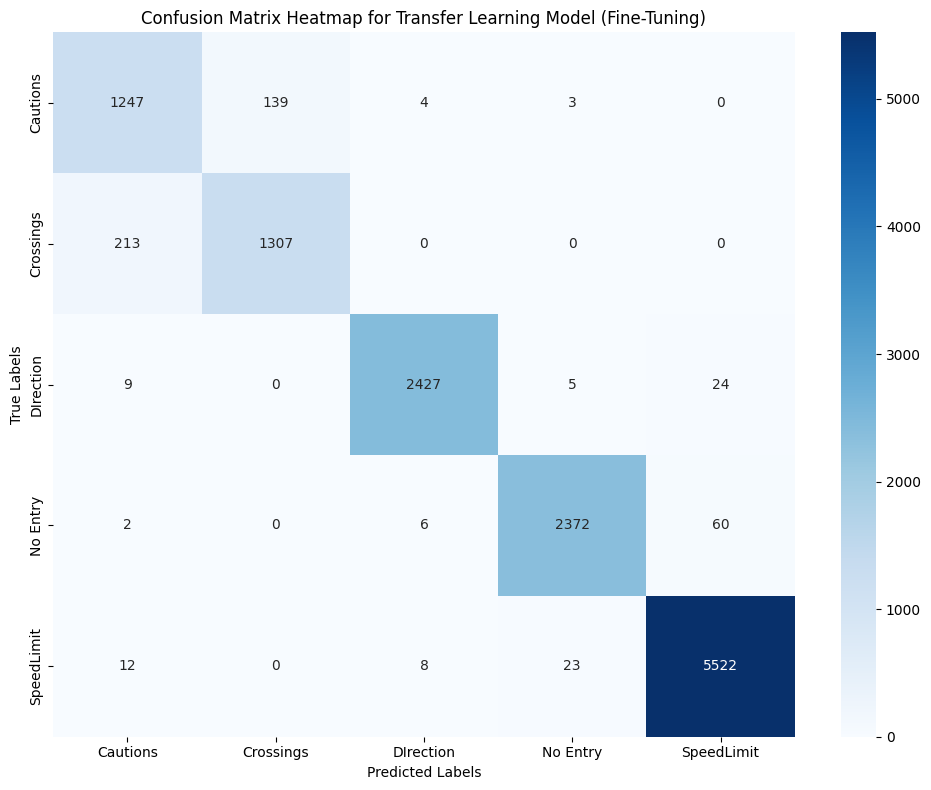

In [27]:
y_true = test_dataset.classes
# y_pred_transfer_fine_tune is available from cell bdd61ed4

# Compute confusion matrix
cm_transfer_fine_tune = confusion_matrix(y_true, y_pred_transfer_fine_tune)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_transfer_fine_tune, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=test_dataset.class_indices.keys(),
            yticklabels=test_dataset.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap for Transfer Learning Model (Fine-Tuning)')
plt.tight_layout()
plt.show()